Building Neural Networks with TensorFlow/Keras
Theory
TensorFlow is an open-source machine learning library developed by Google that allows building and training deep learning models efficiently.

Keras is a high-level API integrated with TensorFlow that simplifies the process of building neural networks by providing easy-to-use abstractions for layers, models, and training routines.

Key Concepts
Sequential API:
Used for creating models layer-by-layer in a linear stack. Ideal for simple feedforward networks.

Functional API:
Allows building complex models with multiple inputs, outputs, or shared layers.

Layers:
Neural networks are built by stacking layers such as:

Dense (fully connected layer)
Conv2D (convolutional layer for images)
LSTM (for sequential data)
Activation functions can be applied via activation parameter or separate layers.
Compiling the Model:
Before training, a model is compiled with:

Optimizer: Method to update weights (SGD, Adam, etc.)
Loss Function: Guides the training (mse, binary_crossentropy, categorical_crossentropy, etc.)
Metrics: To monitor performance (accuracy, mae, etc.)
Training the Model:
Done using model.fit() with:

Training data (X_train, y_train)
Number of epochs (iterations over the dataset)
Batch size (number of samples per weight update)
Validation data (optional) to monitor performance on unseen data.
Evaluating and Predicting:

model.evaluate() to check loss and metrics on test data.
model.predict() to make predictions on new data.
Workflow Summary
Prepare dataset and preprocess.
Build the model using Sequential or Functional API.
Compile the model with optimizer, loss, and metrics.
Train the model with fit().
Evaluate on test data.
Make predictions with predict().
(Optional) Visualize training history (loss/accuracy curves).

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3542 - loss: 1.6819 - val_accuracy: 0.2917 - val_loss: 2.2738
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3542 - loss: 1.5511 - val_accuracy: 0.2917 - val_loss: 2.0509
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3542 - loss: 1.4350 - val_accuracy: 0.2917 - val_loss: 1.8596
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3542 - loss: 1.3428 - val_accuracy: 0.2917 - val_loss: 1.6968
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3542 - loss: 1.2654 - val_accuracy: 0.2917 - val_loss: 1.5672
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3542 - loss: 1.2093 - val_accuracy: 0.2917 - val_loss: 1.4612
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3542 - loss: 1.1656 - val_accuracy: 0.2917 - val_loss: 1.3765
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3542 - loss: 1.1327 - val_accuracy: 0.2917 - val_los

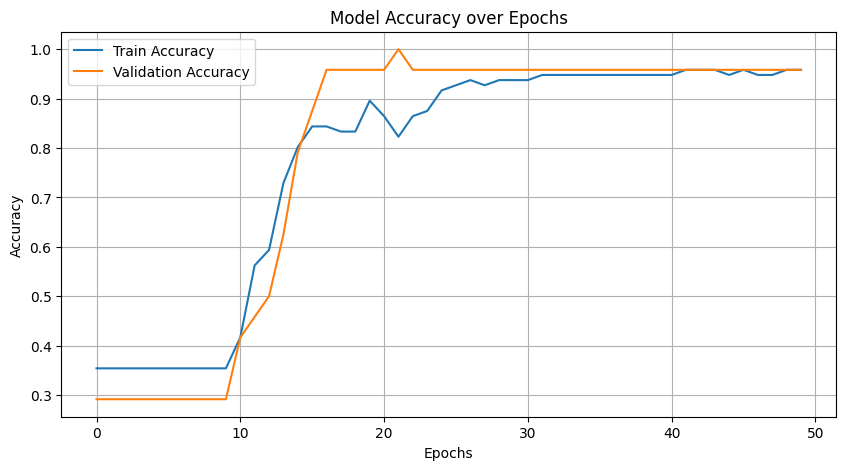

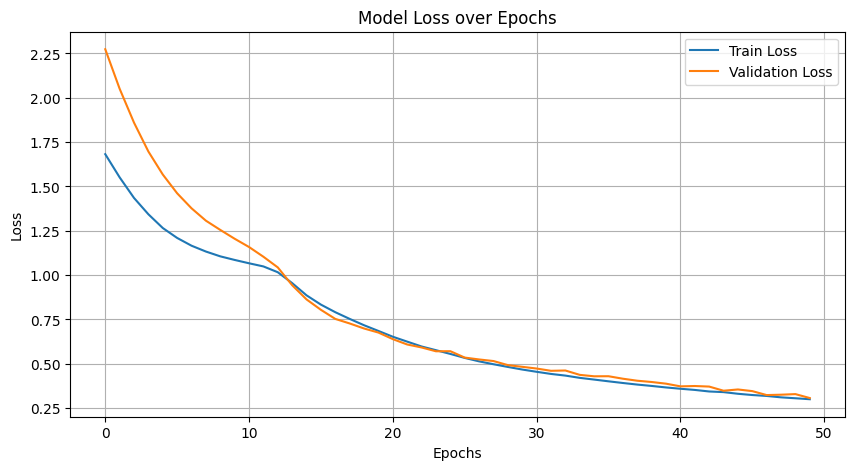

In [1]:
# ==============================
# Building Neural Networks with TensorFlow/Keras
# ==============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 1. Load dataset (Iris dataset)
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# 2. One-hot encode target
encoder = OneHotEncoder(sparse_output=False)  # updated for latest sklearn
y_encoded = encoder.fit_transform(y)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 4. Build Neural Network (Sequential API)
model = Sequential([
    Dense(10, input_shape=(X.shape[1],), activation='relu'),  # Hidden layer
    Dense(8, activation='relu'),                               # Hidden layer
    Dense(y_encoded.shape[1], activation='softmax')           # Output layer
])

# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=8,
    verbose=1
)

# 7. Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 8. Plot training history
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()